In [1]:
%pip install --quiet --upgrade kagglehub

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("ammaraahmad/immigration-to-canada")
filename = "canadian_immegration_data.csv"
filepath = os.path.join(path, filename)

print("Path to dataset files:", path)


Path to dataset files: C:\Users\gg\.cache\kagglehub\datasets\ammaraahmad\immigration-to-canada\versions\1


In [3]:
import pandas as pd

df = pd.read_csv(filepath)
display(df.head())
print("Dataset shape:", df.shape)

categorical_cols = df.select_dtypes(include=["object", "category"]).columns
non_cat_cols = df.columns.difference(categorical_cols)
year_cols = [c for c in non_cat_cols if c.isdigit()]

,Country,Continent,Region,DevName,1980,1981,1982,1983,1984,1985,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
0,Afghanistan,Asia,Southern Asia,Developing regions,16,39,39,47,71,340,...,3436,3009,2652,2111,1746,1758,2203,2635,2004,58639
1,Albania,Europe,Southern Europe,Developed regions,1,0,0,0,0,0,...,1223,856,702,560,716,561,539,620,603,15699
2,Algeria,Africa,Northern Africa,Developing regions,80,67,71,69,63,44,...,3626,4807,3623,4005,5393,4752,4325,3774,4331,69439
3,American Samoa,Oceania,Polynesia,Developing regions,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,6
4,Andorra,Europe,Southern Europe,Developed regions,0,0,0,0,0,0,...,0,1,1,0,0,0,0,1,1,15


Dataset shape: (195, 39)


C:\Users\gg\AppData\Local\Temp\ipykernel_35696\834589390.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object", "category"]).columns


In [4]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

## Missing values and outliers

In [5]:
# Missing values summary
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().mean()*100).sort_values(ascending=False)
missing_df = pd.concat([missing, missing_percent], axis=1, keys=['missing_count','missing_percent'])

# Quick missingness heatmap for columns with any missing values
cols_with_na = missing[missing>0].index.tolist()
if cols_with_na:
    display(missing_df[missing_df.missing_count>0])
    plt.figure(figsize=(10, min(6, len(cols_with_na)*0.3+1)))
    sns.heatmap(df[cols_with_na].isnull(), cbar=False)
    plt.title('Missing values heatmap')
    plt.show()
else:
    print('No missing values detected')

# Outlier detection
outlier_summary = []
for c in non_cat_cols:
    col = df[c].dropna()
    if col.empty:
        continue
    q1, q3 = np.percentile(col, [25,75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    iqr_outliers = ((col < lower) | (col > upper)).sum()
    outlier_summary.append({'column': c, 'iqr_outliers': int(iqr_outliers)})

outlier_df = pd.DataFrame(outlier_summary).sort_values('iqr_outliers', ascending=False)
display(outlier_df.T)

No missing values detected


,0,19,15,2,1,34,3,20,33,16,...,21,24,32,29,7,10,11,13,26,28
column,1980,1999,1995,1982,1981,Total,1983,2000,2013,1996,...,2001,2004,2012,2009,1987,1990,1991,1993,2006,2008
iqr_outliers,31,31,31,30,30,30,30,29,29,29,...,25,25,25,25,24,24,24,24,24,24


## Distributions

In [6]:
display(df[categorical_cols].describe().T)
describer = df.set_index("Country")[year_cols].T.describe().T
describer

,count,unique,top,freq
Country,195,195,Afghanistan,1
Continent,195,6,Africa,54
Region,195,22,Western Asia,18
DevName,195,2,Developing regions,147


,count,mean,std,min,25%,50%,75%,max
Country,,,,,,,,
Afghanistan,34.0,1724.676471,1196.705040,16.0,762.75,1752.0,2615.00,4067.0
Albania,34.0,461.735294,534.982997,0.0,2.25,210.0,712.50,1816.0
Algeria,34.0,2042.323529,1771.709374,44.0,290.00,1948.0,3621.25,5393.0
American Samoa,34.0,0.176471,0.458627,0.0,0.00,0.0,0.00,2.0
Andorra,34.0,0.441176,0.785905,0.0,0.00,0.0,1.00,3.0
...,...,...,...,...,...,...,...,...
Viet Nam,34.0,2857.235294,1674.097424,1191.0,1760.00,2139.5,3341.25,7583.0
Western Sahara,34.0,0.058824,0.238833,0.0,0.00,0.0,0.00,1.0
Yemen,34.0,87.794118,71.695391,0.0,13.50,117.0,140.75,217.0


## Dataset inspection

In [7]:
def compress_years(years):
    years = sorted(years)
    ranges = []
    start = prev = years[0]

    for y in years[1:]:
        if y == prev + 1:
            prev = y
        else:
            ranges.append(f"{start}-{prev}" if start != prev else str(start))
            start = prev = y

    ranges.append(f"{start}-{prev}" if start != prev else str(start))
    return ", ".join(ranges)

In [8]:
top_countries = {}

for c in year_cols:
    year = int(c)
    max_country = df.loc[df[c].idxmax(), "Country"]
    max_immigrants = df[c].max()

    entry = top_countries.setdefault(max_country, {
        "Top immigrants by year": max_immigrants,
        "Top year": year,
        "Years": []
    })

    entry["Years"].append(year)

    if max_immigrants > entry["Top immigrants by year"]:
        entry["Top immigrants by year"] = max_immigrants
        entry["Top year"] = year

top_countries_df = (
    pd.DataFrame(top_countries).T
    .sort_values("Top immigrants by year", ascending=False)
)

top_countries_df["Years"] = top_countries_df["Years"].apply(compress_years)

display(top_countries_df)

,Top immigrants by year,Top year,Years
China,42584,2005,"1998-2005, 2008-2009, 2013"
United Kingdom of Great Britain and Northern Ireland,39231,1994,1980-1997
Philippines,38617,2010,2010-2012
India,33848,2006,2006-2007


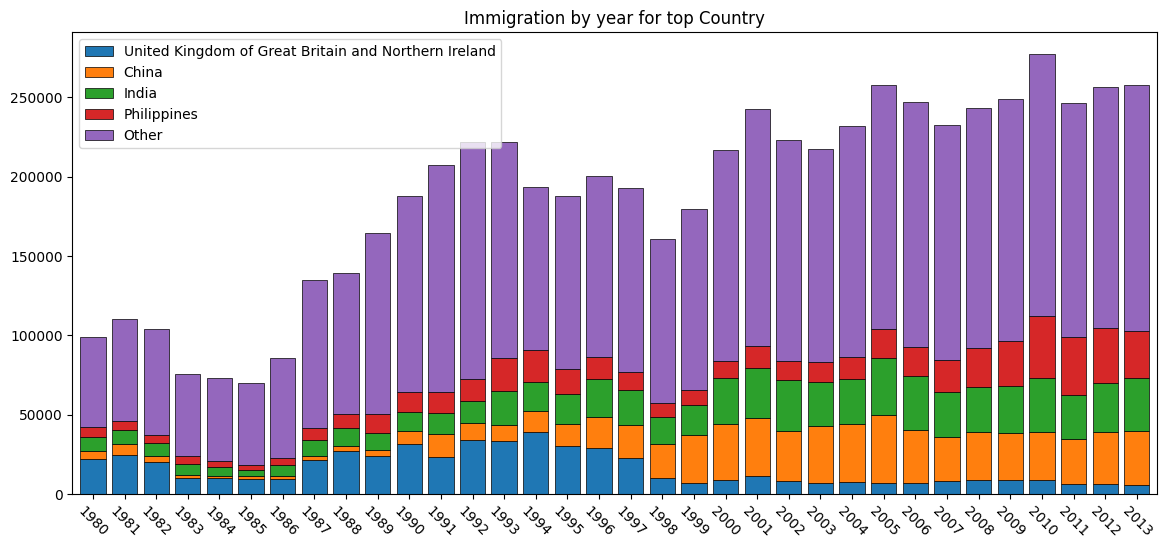

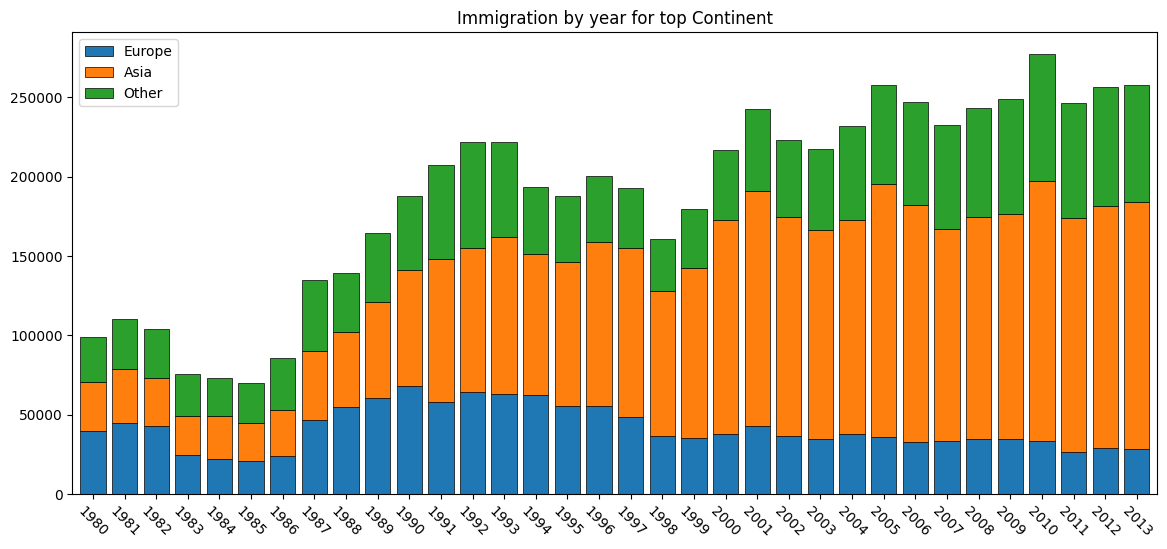

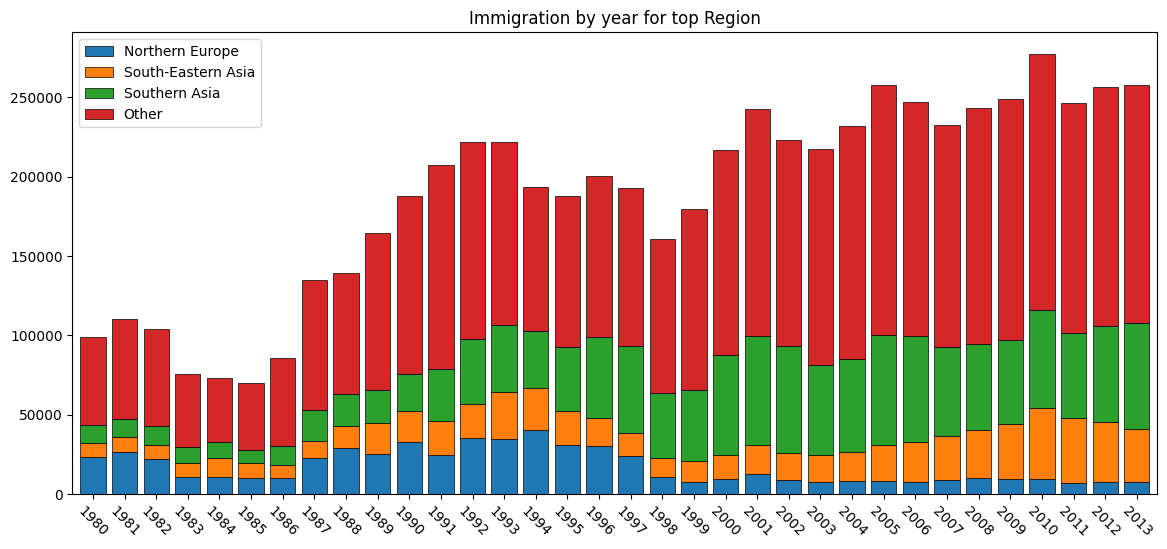

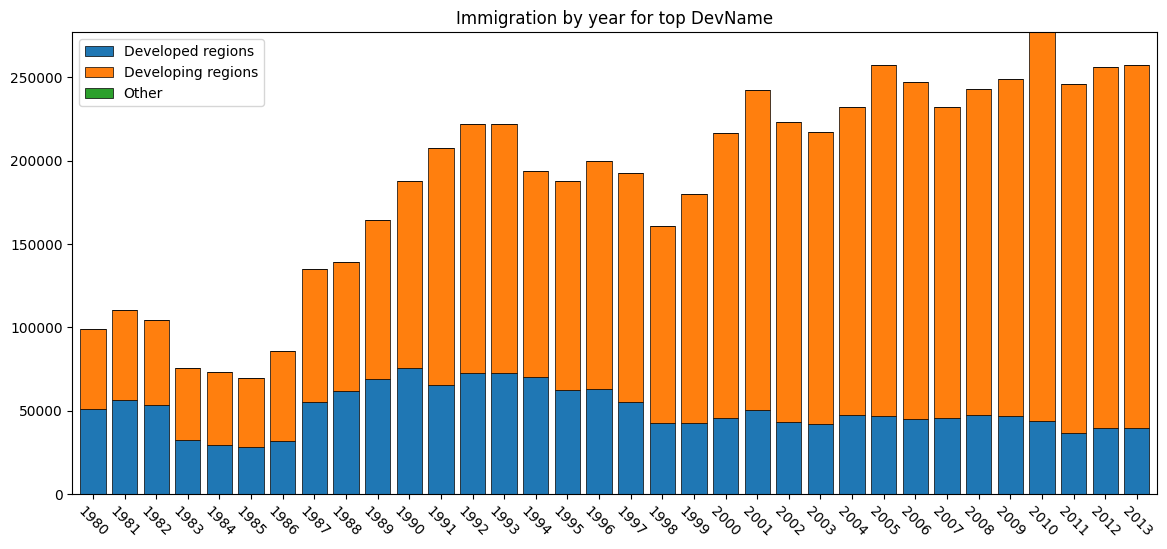

In [9]:
for c in categorical_cols:
    grouped_by_df = df.groupby(c)[year_cols].sum()
    top = grouped_by_df.idxmax(axis=0).unique()

    fig, ax = plt.subplots()
    fig.set_size_inches(14, 6)

    top = grouped_by_df.loc[top][year_cols].T
    other = grouped_by_df.drop(index=top).sum()[year_cols].T
    top_other_df = pd.concat([top, other.rename("Other")], axis=1)
    
    top_other_df.plot(
        ax=ax,
        kind="bar",
        stacked=True,
        edgecolor="black",
        width=0.8,
        linewidth=0.5,
    )

    # categories = top_other_df.columns.unique()
    # palette = dict(zip(categories, sns.color_palette("tab10", len(categories))))

    # for year, y_row in top_other_df.iterrows():
    #     for i, (name, row) in enumerate(y_row.sort_values(ascending=False).items()):
    #         ax.bar(
    #             year,
    #             row,
    #             # width=0.8 - 0.2 * i,
    #             color=palette[name]
    #         )


    ax.set_xticks(range(len(year_cols)))
    ax.set_xticklabels(year_cols, rotation=-45)
    ax.set_title(f"Immigration by year for top {c}")
    ax.legend(loc='upper left')
    plt.show()

## Relationships and correlations

In [ ]:
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output

# ── 0. Prep ───────────────────────────────────────────────────────────────────
year_ints = [int(y) for y in year_cols]

cont_totals = df.groupby('Continent')['Total'].sum().reset_index()
continents = cont_totals['Continent'].tolist()
palette = px.colors.qualitative.Set2
cont_color = {c: palette[i % len(palette)] for i, c in enumerate(continents)}

# ── 1. Correlation helper ─────────────────────────────────────────────────────
def top_correlated(country_name, n=5):
    target = df[df['Country'] == country_name][year_cols].values.flatten().astype(float)
    others = df[df['Country'] != country_name].copy()
    corrs = others[year_cols].apply(
        lambda row: np.corrcoef(target, row.values.astype(float))[0, 1], axis=1
    )
    others['corr'] = corrs.values
    return others.nlargest(n, 'corr')[['Country', 'Continent', 'Total', 'corr']]

# ── 2. Chart builders ─────────────────────────────────────────────────────────
def make_treemap():
    fig = go.Figure(go.Treemap(
        labels=cont_totals['Continent'].tolist(),
        parents=[''] * len(cont_totals),
        values=cont_totals['Total'].tolist(),
        marker_colors=[cont_color[c] for c in cont_totals['Continent']],
        texttemplate="<b>%{label}</b><br>%{value:,}",
        hovertemplate="<b>%{label}</b><br>Total immigrants: %{value:,}<extra></extra>",
        textfont_size=16,
    ))
    fig.update_layout(
        title=dict(text="Immigration to Canada 1980–2013 by continent", font_size=15),
        margin=dict(t=50, l=10, r=10, b=10),
        height=380,
        paper_bgcolor='white',
    )
    return fig

def make_continent_chart(continent_name):
    sub = df[df['Continent'] == continent_name].sort_values('Total', ascending=True)
    fig = go.Figure(go.Bar(
        x=sub['Total'],
        y=sub['Country'],
        orientation='h',
        marker_color=cont_color[continent_name],
        hovertemplate="<b>%{y}</b><br>Total: %{x:,}<extra></extra>",
    ))
    fig.update_layout(
        title=dict(text=f"<b>{continent_name}</b> — countries by total immigration", font_size=14),
        xaxis_title='Total immigrants 1980–2013',
        height=max(350, len(sub) * 22 + 80),
        paper_bgcolor='white',
        margin=dict(t=50, l=160, r=20, b=50),
    )
    return fig

def make_country_detail(country_name):
    row = df[df['Country'] == country_name].iloc[0]
    continent = row['Continent']
    color = cont_color[continent]
    y_vals = row[year_cols].values.astype(float)
    corr_df = top_correlated(country_name, n=5)
    fillcolor = (
        color.replace('rgb', 'rgba').replace(')', ', 0.15)')
        if color.startswith('rgb') else color
    )
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=[
            f"<b>{country_name}</b> — immigration by year",
            "Top 5 most correlated countries",
        ],
        column_widths=[0.58, 0.42],
    )
    fig.add_trace(go.Scatter(
        x=year_ints, y=y_vals,
        mode='lines+markers',
        line=dict(color=color, width=2.5),
        marker=dict(size=5),
        fill='tozeroy',
        fillcolor=fillcolor,
        hovertemplate="Year: %{x}<br>Immigrants: %{y:,}<extra></extra>",
        name=country_name,
    ), row=1, col=1)
    bar_colors = [cont_color.get(c, '#aaa') for c in corr_df['Continent']]
    fig.add_trace(go.Bar(
        x=corr_df['corr'],
        y=corr_df['Country'],
        orientation='h',
        marker_color=bar_colors,
        text=[f"{v:.2f}" for v in corr_df['corr']],
        textposition='outside',
        hovertemplate="<b>%{y}</b><br>Correlation: %{x:.3f}<br>Total: %{customdata:,}<extra></extra>",
        customdata=corr_df['Total'].values,
    ), row=1, col=2)
    fig.update_xaxes(title_text='Year', row=1, col=1)
    fig.update_yaxes(title_text='Immigrants', row=1, col=1)
    fig.update_xaxes(title_text='Pearson r', range=[0, 1.1], row=1, col=2)
    fig.update_yaxes(categoryorder='total ascending', row=1, col=2)
    fig.update_layout(
        height=380, showlegend=False, paper_bgcolor='white',
        margin=dict(t=60, l=20, r=40, b=50),
        title=dict(text=f"Detail view — {country_name} ({continent})", font_size=14),
    )
    return fig

# ── 3. Dropdown UI (no FigureWidget / anywidget needed) ───────────────────────
# VS Code remote SSH cannot load anywidget's JS across the remote boundary, so
# FigureWidget click handlers silently fail there. This version uses standard
# ipywidgets Dropdowns (fully supported) to drive the same three-level drill-down.
# Static go.Figure + .show() renders fine without any widget JS.

breadcrumb = widgets.HTML(value="<b>🌍 World</b>")

continent_dd = widgets.Dropdown(
    options=continents,
    value=continents[0],
    description='Continent:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='260px'),
)
country_dd = widgets.Dropdown(
    options=[],
    description='Country:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='300px'),
)

out_treemap = widgets.Output()
out_cont    = widgets.Output()
out_country = widgets.Output()

def update_breadcrumb():
    parts = ["<b>🌍 World</b>"]
    if continent_dd.value:
        parts.append(f"<b>{continent_dd.value}</b>")
    if country_dd.value:
        parts.append(f"<b>{country_dd.value}</b>")
    breadcrumb.value = " › ".join(parts)

def on_continent_change(change):
    continent = change['new']
    countries = (
        df[df['Continent'] == continent]
        .sort_values('Total', ascending=False)['Country'].tolist()
    )
    # Unobserve to avoid double-firing when options reset triggers value change
    country_dd.unobserve(on_country_change, names='value')
    country_dd.options = countries
    country_dd.value = countries[0] if countries else None
    country_dd.observe(on_country_change, names='value')

    update_breadcrumb()
    with out_cont:
        clear_output(wait=True)
        make_continent_chart(continent).show()
    if countries:
        with out_country:
            clear_output(wait=True)
            make_country_detail(countries[0]).show()

def on_country_change(change):
    country = change['new']
    if not country:
        return
    update_breadcrumb()
    with out_country:
        clear_output(wait=True)
        make_country_detail(country).show()

continent_dd.observe(on_continent_change, names='value')
country_dd.observe(on_country_change, names='value')

# Initial render
with out_treemap:
    make_treemap().show()

on_continent_change({'new': continents[0]})

display(widgets.VBox([
    breadcrumb,
    out_treemap,
    widgets.HBox([continent_dd, country_dd]),
    out_cont,
    out_country,
]))